# Lab 2: Computational Methods in Python

## 0. Setup

In [1]:
# Import libraries
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sklearn, gensim, torch, transformers

print(f"scikit-learn:  {sklearn.__version__}")
print(f"gensim:        {gensim.__version__}")
print(f"torch:         {torch.__version__}")
print(f"transformers:  {transformers.__version__}")

scikit-learn:  1.9.0
gensim:        4.4.0
torch:         2.14.0
transformers:  5.16.1


## 1. Word-embedding

In [2]:
import gensim.downloader as api

In [3]:
glove = api.load("glove-wiki-gigaword-100")    # 400,000 words × 100 dimensions
print(f"vocabulary: {len(glove.index_to_key):,} words")
print(f"the vector for 'sociology' has {len(glove['sociology'])} numbers")
print(glove["sociology"][:8].round(3))

vocabulary: 400,000 words
the vector for 'sociology' has 100 numbers
[ 0.461 -0.225 -0.163  0.525  0.944 -0.179  0.59  -0.45 ]


In [4]:
for w in ["rich", "protest", "immigrant", "family"]:
    print(f"{w:10s} → {', '.join(x for x, _ in glove.most_similar(w, topn=6))}")

rich       → especially, wealthy, richer, vast, diverse, particularly
protest    → protests, protesting, demonstrations, demonstration, protesters, protested
immigrant  → immigrants, migrant, migrants, immigration, citizen, undocumented
family     → father, mother, friends, parents, families, whose


In [5]:
print(glove.most_similar(positive=["king", "woman"], negative=["man"], topn=3))

[('queen', 0.7698541283607483), ('monarch', 0.6843380928039551), ('throne', 0.6755736470222473)]


In [6]:
def make_dimension(pairs):
    """Average the difference vectors of several antonym pairs → one direction."""
    diffs = []
    for a, b in pairs:
        va = glove[a] / np.linalg.norm(glove[a])
        vb = glove[b] / np.linalg.norm(glove[b])
        diffs.append(va - vb)
    d = np.mean(diffs, axis=0)
    return d / np.linalg.norm(d)

In [7]:
def project(word, dimension):
    """Cosine similarity of a normalized word vector with the dimension."""
    v = glove[word] / np.linalg.norm(glove[word])
    return float(v @ dimension)

In [8]:
class_dim  = make_dimension([("rich", "poor"), ("wealthy", "impoverished"),
                             ("affluent", "needy"), ("luxury", "cheap")])
gender_dim = make_dimension([("man", "woman"), ("he", "she"),
                             ("his", "her"), ("male", "female")])

items = ["nurse", "nanny", "teacher", "carpenter", "engineer", "lawyer",
         "golf", "tennis", "boxing", "bowling", "hockey",
         "opera", "ballet", "jazz", "rap", "caviar", "beer", "wine", "yacht", "truck"]

In [9]:
project("nurse", class_dim)

-0.2126845419406891

In [10]:
project("nurse", gender_dim)

-0.35237085819244385

In [11]:
proj = pd.DataFrame({
    "class":  [project(w, class_dim)  for w in items],
    "gender": [project(w, gender_dim) for w in items],
}, index=items)

print(proj.sort_values("class").round(3))

           class  gender
nurse     -0.213  -0.352
nanny     -0.127  -0.276
teacher   -0.092  -0.123
bowling   -0.029   0.225
boxing     0.009   0.123
carpenter  0.014   0.010
rap        0.023   0.039
engineer   0.050   0.120
hockey     0.056   0.150
truck      0.103   0.031
ballet     0.123  -0.150
jazz       0.137   0.118
tennis     0.139  -0.058
caviar     0.140  -0.097
opera      0.153  -0.115
lawyer     0.157   0.027
beer       0.202  -0.003
golf       0.262   0.099
wine       0.299   0.014
yacht      0.336  -0.022


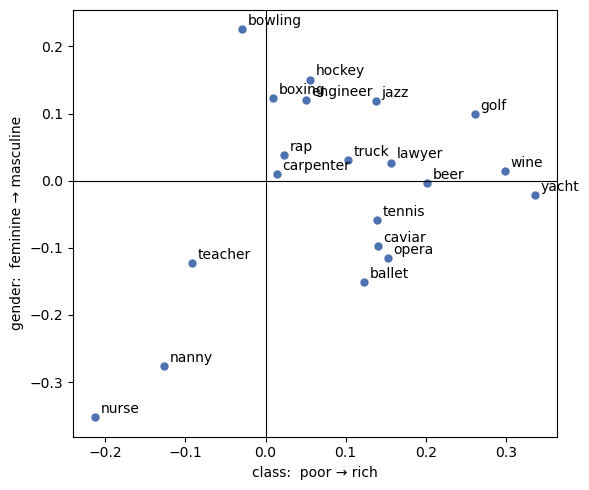

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
ax.scatter(proj["class"], proj["gender"], s=25, color="#4C72B0")
for w, row in proj.iterrows():
    ax.annotate(w, (row["class"], row["gender"]), fontsize=10,
                textcoords="offset points", xytext=(4, 3))
ax.set_xlabel("class:  poor → rich")
ax.set_ylabel("gender:  feminine → masculine")
plt.tight_layout(); plt.show()

In [20]:
cos = float(class_dim @ gender_dim) #calculate cosine similarity between class and gender dimensions
print(f"cosine between class and gender dimensions: {cos:.3f}") #print the cosine similarity rounded to 3 decimal places

angle = np.degrees(np.arccos(cos)) #calculate the angle in degrees between the two dimensions
print(f"angle: {angle:.1f}°") #print the angle rounded to 1 decimal place

cosine between class and gender dimensions: 0.040
angle: 87.7°


## 2. Bert

In [2]:
import torch
from transformers import AutoTokenizer, AutoModel

In [3]:
MODEL = "distilbert-base-uncased"      # a smaller, faster BERT
tok   = AutoTokenizer.from_pretrained(MODEL)
bert  = AutoModel.from_pretrained(MODEL).eval()

print(tok.tokenize("Rhetorics of radicalism in unedited newsgroup prose"))

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


['rhetoric', '##s', 'of', 'radical', '##ism', 'in', 'une', '##dit', '##ed', 'news', '##group', 'prose']


In [4]:
def word_vector(sentence, word):
    """The contextual vector BERT gives one word inside one sentence."""
    batch = tok(sentence, return_tensors="pt")
    with torch.no_grad():
        hidden = bert(**batch).last_hidden_state[0]        # tokens × 768
    pieces = tok.convert_ids_to_tokens(batch["input_ids"][0])
    rows   = [i for i, pc in enumerate(pieces) if pc == word]
    return hidden[rows].mean(0).numpy()

def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

In [5]:
river  = word_vector("We sat on the river bank and watched the water.", "bank")
money  = word_vector("She went to the bank to deposit her paycheck.",   "bank")
loan   = word_vector("The bank approved the mortgage loan yesterday.",  "bank")

print(f"bank (river) vs bank (deposit): {cosine(river, money):.3f}")
print(f"bank (deposit) vs bank (loan):  {cosine(money, loan):.3f}")

bank (river) vs bank (deposit): 0.679
bank (deposit) vs bank (loan):  0.894


In [26]:
from sklearn.datasets import fetch_20newsgroups

# a list of groups to keep
CATS = ["talk.politics.guns", "talk.politics.mideast",
        "talk.religion.misc", "sci.space"]

# create the corpus, keeping only the specified groups, removing headers, footers, and quoted replies
news = fetch_20newsgroups(subset="all", categories=CATS,
                          remove=("headers", "footers", "quotes"),
                          shuffle=True, random_state=42)

# Drop very short posts (one-line replies carry no signal)
docs   = [d for d in news.data if len(d.split()) >= 20]

# Create a label/outcome array: 1 if the post is about religion, 0 otherwise
labels = [news.target[i] for i, d in enumerate(news.data) if len(d.split()) >= 20]

print(f"{len(docs)} documents in {len(news.target_names)} groups")
print(news.target_names)
print("\n--- one example ---\n")
print(docs[0][:400])

3101 documents in 4 groups
['sci.space', 'talk.politics.guns', 'talk.politics.mideast', 'talk.religion.misc']

--- one example ---



'Alone'? Sorry, but the following western scholars are forced to disagree 
with you. During the First World War and the ensuing years - 1914-1920, 
the Armenians through a premeditated and systematic genocide, 
tried to complete its centuries-old policy of annihilation against 
the Turks and Kurds by savagely murdering 2.5 million Muslims and 
deporting the rest from their 1,000 year homeland.




In [27]:
# The train_test_split function randomly splits the data into training and test sets
from sklearn.model_selection import train_test_split

# Define the positive class (religion) as 1, and the negative class (non-religion) as 0
y = np.array([1 if news.target_names[l] == "talk.religion.misc" else 0 for l in labels])

# Print the proportion of positive class in the dataset: imbalanced, like most real tasks
print(f"positive class: {y.mean():.1%} of documents") 


# Split the data into training and test sets, stratifying by the label to maintain class balance
i_train, i_test = train_test_split(np.arange(len(docs)), test_size=0.3,
                                   random_state=42, stratify=y)
print(f"train: {len(i_train)}   test: {len(i_test)}")

positive class: 17.4% of documents
train: 2170   test: 931


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Create a tf-idf vectorizer with some filtering: 
#   ignore English stop words, 
#   keep only words that appear in at least 3 documents and in at most 60% of documents, 
#   consider unigrams and bigrams. 
#   Use sublinear tf scaling (1 + log(tf)) to reduce the impact of very frequent terms.
vec = TfidfVectorizer(stop_words="english", min_df=3, max_df=0.6,
                      ngram_range=(1, 2), sublinear_tf=True)

# Fit the vectorizer on the training documents and transform both training and test into tf-idf matrices
X_train = vec.fit_transform([docs[i] for i in i_train])
X_test  = vec.transform([docs[i] for i in i_test])

# Fit a logistic regression model on the training data and predict probabilities on the test data
clf_tfidf = LogisticRegression(max_iter=2000).fit(X_train, y[i_train])
p_tfidf   = clf_tfidf.predict_proba(X_test)[:, 1]   

# Print the first 8 predicted probabilities rounded to 3 decimal places
print(p_tfidf[:8].round(3))

[0.219 0.159 0.133 0.115 0.093 0.156 0.177 0.076]


In [29]:
feat  = np.array(vec.get_feature_names_out())
order = clf_tfidf.coef_[0].argsort()
print("most 'religion':", ", ".join(feat[order[::-1][:12]]))
print("least 'religion':", ", ".join(feat[order[:12]]))

most 'religion': god, jesus, christian, kent, bible, cheers kent, cheers, objective, evidence, koresh, religion, christians
least 'religion': space, israel, gun, arab, israeli, year, nasa, orbit, control, government, rights, arabs


In [30]:
# a function to convert a list of texts into BERT embeddings
def embed(texts, batch_size=16, max_length=128):
    """Mean-pool BERT's last layer → one 768-number vector per document."""
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = tok(texts[i:i+batch_size], padding=True, truncation=True,
                        max_length=max_length, return_tensors="pt")
            hidden = bert(**batch).last_hidden_state           # tokens × 768
            mask   = batch["attention_mask"].unsqueeze(-1).float()
            out.append(((hidden * mask).sum(1) / mask.sum(1)).numpy())
    return np.vstack(out)

# embed the first 2000 characters of each document to get a 768-dimensional vector for each document
E = embed([d[:2000] for d in docs])    

# print the shape of the resulting embedding matrix
print(f"BERT features: {E.shape}")

BERT features: (3101, 768)


In [31]:
clf_bert = LogisticRegression(max_iter=3000).fit(E[i_train], y[i_train])
p_bert   = clf_bert.predict_proba(E[i_test])[:, 1]
print(p_bert[:8].round(3))

[0.207 0.056 0.235 0.018 0.004 0.009 0.083 0.007]


In [32]:
from datasets import Dataset
from transformers import (AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, DataCollatorWithPadding)

train_i, test_i = i_train[:400], i_test[:150]

def to_dataset(idxs):
    d = Dataset.from_dict({"text":  [docs[i][:2000] for i in idxs],
                           "label": [int(y[i]) for i in idxs]})
    return d.map(lambda b: tok(b["text"], truncation=True, max_length=128), batched=True)

model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=2)
args  = TrainingArguments(output_dir="./bert_out", num_train_epochs=1,
                          per_device_train_batch_size=8, per_device_eval_batch_size=16,
                          learning_rate=5e-5, logging_steps=25,
                          save_strategy="no", eval_strategy="no",
                          report_to=[], use_cpu=True)

trainer = Trainer(model=model, args=args,
                  train_dataset=to_dataset(train_i), eval_dataset=to_dataset(test_i),
                  data_collator=DataCollatorWithPadding(tok))   # pads each batch to equal length
trainer.train()

logits = trainer.predict(to_dataset(test_i)).predictions
p_ft   = np.exp(logits[:, 1]) / np.exp(logits).sum(1)
print(p_ft[:8].round(3))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Step,Training Loss
25,0.406905
50,0.371641


Map:   0%|          | 0/150 [00:00<?, ? examples/s]

[0.035 0.075 0.062 0.038 0.042 0.036 0.056 0.028]


In [36]:
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             average_precision_score, roc_curve, precision_recall_curve)

y_test = y[i_test]

def report(y_true, scores, threshold=0.1, name=""):
    pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    print(f"--- {name} (threshold = {threshold}) ---")
    print(f"true positives  {tp:4d}    false positives {fp:4d}")
    print(f"false negatives {fn:4d}    true negatives  {tn:4d}")
    print(f"accuracy  {accuracy_score(y_true, pred):.3f}"
          f"   precision {precision_score(y_true, pred, zero_division=0):.3f}"
          f"   recall {recall_score(y_true, pred):.3f}"
          f"   F1 {f1_score(y_true, pred):.3f}")
    print(f"ROC-AUC   {roc_auc_score(y_true, scores):.3f}"
          f"   PR-AUC {average_precision_score(y_true, scores):.3f}\n")

# tf-idf and frozen BERT were both scored on all 931 test documents
report(y_test, p_tfidf, 0.1, "tf-idf + logistic regression")
report(y_test, p_bert,  0.1, "frozen BERT + logistic regression")

# The fine-tuned model was evaluated on only 150 documents (test_i = i_test[:150]),
# so we score it on those same 150 for a fair, apples-to-apples comparison.
y_ft_test = y[test_i]
report(y_ft_test, p_ft, 0.1, "fine-tuned BERT @ threshold 0.5")

--- tf-idf + logistic regression (threshold = 0.1) ---
true positives   162    false positives  486
false negatives    0    true negatives   283
accuracy  0.478   precision 0.250   recall 1.000   F1 0.400
ROC-AUC   0.963   PR-AUC 0.892

--- frozen BERT + logistic regression (threshold = 0.1) ---
true positives   147    false positives  127
false negatives   15    true negatives   642
accuracy  0.847   precision 0.536   recall 0.907   F1 0.674
ROC-AUC   0.953   PR-AUC 0.876

--- fine-tuned BERT @ threshold 0.5 (threshold = 0.1) ---
true positives    11    false positives   17
false negatives    7    true negatives   115
accuracy  0.840   precision 0.393   recall 0.611   F1 0.478
ROC-AUC   0.813   PR-AUC 0.633



In [35]:
# Pick a threshold that flags the top ~17% of predicted scores (matching the true base rate)
thr_ft = float(np.quantile(p_ft, 1 - y_ft_test.mean()))
print(f"score distribution: min={p_ft.min():.3f}  max={p_ft.max():.3f}  "
      f"share above 0.5: {(p_ft >= 0.5).mean():.1%}")
print(f"calibrated threshold: {thr_ft:.3f}\n")

report(y_ft_test, p_ft, thr_ft, "fine-tuned BERT (calibrated threshold)")

score distribution: min=0.025  max=0.451  share above 0.5: 0.0%
calibrated threshold: 0.156

--- fine-tuned BERT (calibrated threshold) (threshold = 0.15582571327686312) ---
true positives    10    false positives    8
false negatives    8    true negatives   124
accuracy  0.893   precision 0.556   recall 0.556   F1 0.556
ROC-AUC   0.813   PR-AUC 0.633

